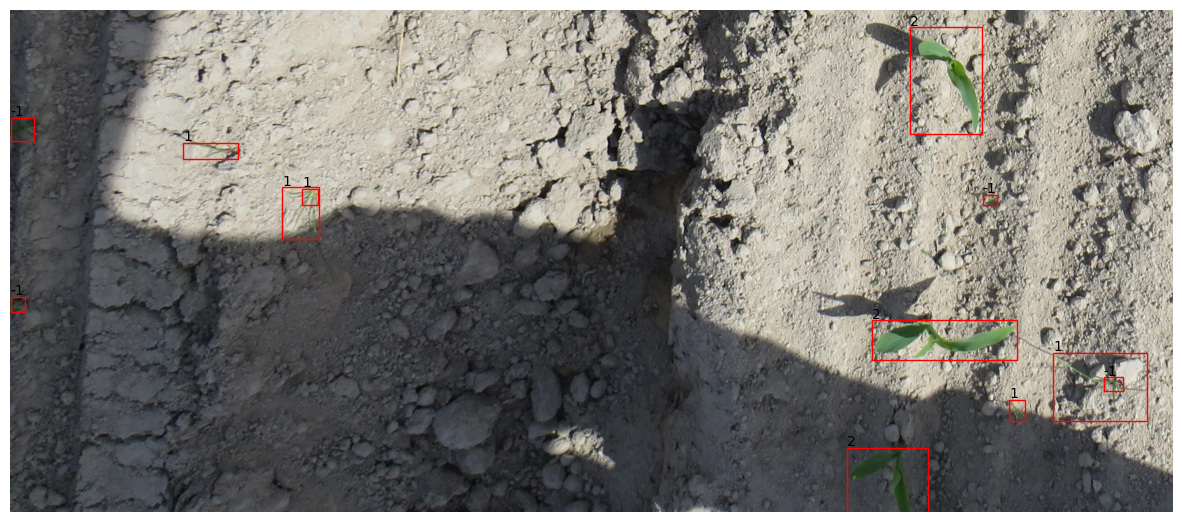

In [1]:
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt

from green_melon import PascalBbox, plot_img_with_bboxes, WEEDMAIZE, GREEN_MELON

IMAGES_DIR = Path("data/weedmaize/images")
LABELS_DIR = Path("data/weedmaize/pascal_labels")

images = list(IMAGES_DIR.glob("*.JPG"))
img_path = random.choice(images)
lbl_path = LABELS_DIR / (img_path.name + ".json")

with lbl_path.open() as f:
    annots = json.load(f)

bboxes = []
for obj in annots["objects"]:
    class_name = obj["classTitle"]
    class_id = WEEDMAIZE[class_name]

    (xmin, ymin), (xmax, ymax) = obj["points"]["exterior"]
    
    pascal = PascalBbox(xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax)
    bboxes.append((pascal, class_id))

fig, ax = plot_img_with_bboxes(image_path=img_path, annots=bboxes)
plt.show()